In [1]:
import pandas as pd
import sys
from pathlib import Path

from sklearn.metrics import fbeta_score, make_scorer

# Works whether kernel cwd is project root or notebooks/
cwd = Path.cwd().resolve()
if (cwd / "src").exists():
    src_path = cwd / "src"
elif (cwd.parent / "src").exists():
    src_path = cwd.parent / "src"
else:
    raise RuntimeError("Could not find src/ directory")

sys.path.insert(0, str(src_path))

from exoplanet_detector.config import DEFAULT_RUN_TAG, K2P_FILE, KOI_TEST_FILE, get_run_artifact_dirs
from exoplanet_detector.features.feature_selection import FINAL_FEATURE_COLUMNS
from exoplanet_detector.models.feature_analysis import (
    build_evaluation_sets,
    build_feature_importance_matrix,
    compute_or_load_permutation_importance,
    get_feature_analysis_paths,
    load_deployed_models,
    predict_and_explain_single_row,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


In [2]:
RUN_TAG = DEFAULT_RUN_TAG
run_dirs = get_run_artifact_dirs(RUN_TAG, create=True)

DEPLOYMENT_ARTIFACT_DIR = run_dirs["deployment"]
DEPLOY_MODELS_PATH = DEPLOYMENT_ARTIFACT_DIR / "deploy_models.joblib"

FEATURE_ANALYSIS_PATHS = get_feature_analysis_paths(RUN_TAG, create=True)
PERMUTATION_IMPORTANCE_PATH = FEATURE_ANALYSIS_PATHS["permutation_importance_path"]
FEATURE_ANALYSIS_META_PATH = FEATURE_ANALYSIS_PATHS["feature_analysis_meta_path"]
FEATURE_IMPORTANCE_MATRIX_PATH = FEATURE_ANALYSIS_PATHS["feature_importance_matrix_path"]

deployed_models, deployed_model_registry_df = load_deployed_models(DEPLOY_MODELS_PATH)

print(f"Feature-analysis artifacts: {FEATURE_ANALYSIS_PATHS['artifact_dir']}")
deployed_model_registry_df

Feature-analysis artifacts: /Users/janma/Desktop/exoplanet-detection/artifacts/feature_analysis/v1


,deploy_id,model_name,profile,threshold
0,deploy_f2,knn,f2,0.363636
1,deploy_precision,hgb,precision_constrained,0.885432
2,deploy_recall,rf,recall_constrained,0.029039


In [3]:
KOI_test_set = pd.read_csv(KOI_TEST_FILE)
K2P_set = pd.read_csv(K2P_FILE)

In [4]:
evaluation_sets = build_evaluation_sets(
    KOI_test_set,
    K2P_set,
    feature_columns=FINAL_FEATURE_COLUMNS,
    include_combined=True,
)

In [5]:
FORCE_RECOMPUTE_FEATURE_ANALYSIS = False
N_REPEATS = 20
PERMUTATION_RANDOM_STATE = 42
PERMUTATION_N_JOBS = 1
USE_PROFILE_SCORING = True

permutation_importance_df, feature_analysis_meta, loaded_from_cache = compute_or_load_permutation_importance(
    deployed_models,
    evaluation_sets,
    run_tag=RUN_TAG,
    permutation_importance_path=PERMUTATION_IMPORTANCE_PATH,
    feature_analysis_meta_path=FEATURE_ANALYSIS_META_PATH,
    use_profile_scoring=USE_PROFILE_SCORING,
    n_repeats=N_REPEATS,
    random_state=PERMUTATION_RANDOM_STATE,
    n_jobs=PERMUTATION_N_JOBS,
    force_recompute=FORCE_RECOMPUTE_FEATURE_ANALYSIS,
)

if loaded_from_cache:
    print(f"Loaded cached permutation importance: {PERMUTATION_IMPORTANCE_PATH}")
else:
    print(f"Saved permutation importance: {PERMUTATION_IMPORTANCE_PATH}")
    print(f"Saved metadata: {FEATURE_ANALYSIS_META_PATH}")

permutation_importance_df

Saved permutation importance: /Users/janma/Desktop/exoplanet-detection/artifacts/feature_analysis/v1/permutation_importance.csv
Saved metadata: /Users/janma/Desktop/exoplanet-detection/artifacts/feature_analysis/v1/feature_analysis_meta.json


,deploy_id,model_name,profile,threshold,dataset,feature,importance_mean,importance_std,n_repeats,scoring,importance_rank
0,deploy_f2,knn,f2,0.363636,K2P,orbital_period_days,0.039938,0.007426,20,f2,1
1,deploy_f2,knn,f2,0.363636,K2P,transit_duration_hours,0.030641,0.004361,20,f2,2
2,deploy_f2,knn,f2,0.363636,K2P,transit_depth,0.017684,0.006941,20,f2,3
3,deploy_f2,knn,f2,0.363636,K2P,a_over_rs,0.016489,0.004517,20,f2,4
4,deploy_f2,knn,f2,0.363636,K2P,stellar_metallicity_dex,0.016095,0.004451,20,f2,5
...,...,...,...,...,...,...,...,...,...,...,...
94,deploy_recall,rf,recall_constrained,0.029039,KOI_test_plus_K2P,transit_depth,-0.000753,0.000316,20,recall,6
95,deploy_recall,rf,recall_constrained,0.029039,KOI_test_plus_K2P,stellar_logg_cgs,-0.000886,0.000280,20,recall,7
96,deploy_recall,rf,recall_constrained,0.029039,KOI_test_plus_K2P,stellar_teff_k,-0.001063,0.000354,20,recall,8
97,deploy_recall,rf,recall_constrained,0.029039,KOI_test_plus_K2P,inclination_deg,-0.001151,0.000567,20,recall,9


In [6]:
feature_importance_matrix_df = build_feature_importance_matrix(
    permutation_importance_df,
    deploy_ids=list(deployed_models.keys()),
    dataset_names=list(evaluation_sets.keys()),
    feature_order=FINAL_FEATURE_COLUMNS,
)

feature_importance_matrix_df.to_csv(FEATURE_IMPORTANCE_MATRIX_PATH, index=False)
print(f"Saved feature importance matrix: {FEATURE_IMPORTANCE_MATRIX_PATH}")
print(f"Matrix shape: {feature_importance_matrix_df.shape}")
feature_importance_matrix_df

Saved feature importance matrix: /Users/janma/Desktop/exoplanet-detection/artifacts/feature_analysis/v1/feature_importance_matrix.csv
Matrix shape: (11, 10)


model_dataset,feature,deploy_f2__KOI_test,deploy_f2__K2P,deploy_f2__KOI_test_plus_K2P,deploy_recall__KOI_test,deploy_recall__K2P,deploy_recall__KOI_test_plus_K2P,deploy_precision__KOI_test,deploy_precision__K2P,deploy_precision__KOI_test_plus_K2P
0,orbital_period_days,0.074617,0.039938,0.072628,0.000000,0.000259,0.000664,0.002384,0.003648,0.004522
1,impact_parameter,0.019767,0.005691,0.001050,-0.000273,-0.000603,-0.000709,0.010465,0.002569,0.005837
2,transit_duration_hours,0.058593,0.030641,0.062038,-0.000091,0.000000,-0.000089,0.003771,0.000922,0.003711
3,transit_depth,0.053896,0.017684,0.031936,0.000182,-0.000862,-0.000753,0.042256,0.036034,0.041141
4,inclination_deg,0.022984,-0.000823,0.007216,-0.001093,0.000431,-0.001151,0.001149,0.000133,-0.001124
5,a_over_rs,0.032001,0.016489,0.024727,0.000000,-0.000948,-0.000709,0.017461,0.015795,0.014991
6,planet_radius_rearth,0.076522,0.002708,0.038951,-0.000546,-0.000690,-0.001151,0.039705,0.001386,0.024208
7,insolation_earth,0.030800,0.004623,0.019758,0.000000,-0.000086,-0.000620,0.002451,0.000054,0.000760
8,stellar_teff_k,0.014325,-0.001042,0.009430,0.000000,-0.001638,-0.001063,0.013796,0.001978,0.009287
9,stellar_logg_cgs,0.020333,-0.005813,0.005920,0.000000,-0.001638,-0.000886,0.012006,0.004838,0.012258


The table displays each feature's permutation importance for each (model x dataset) pair. Some values are negative, which is not problematic.

/Users/janma/Desktop/exoplanet-detection/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 1/1 [00:01<00:00,  1.79s/it]


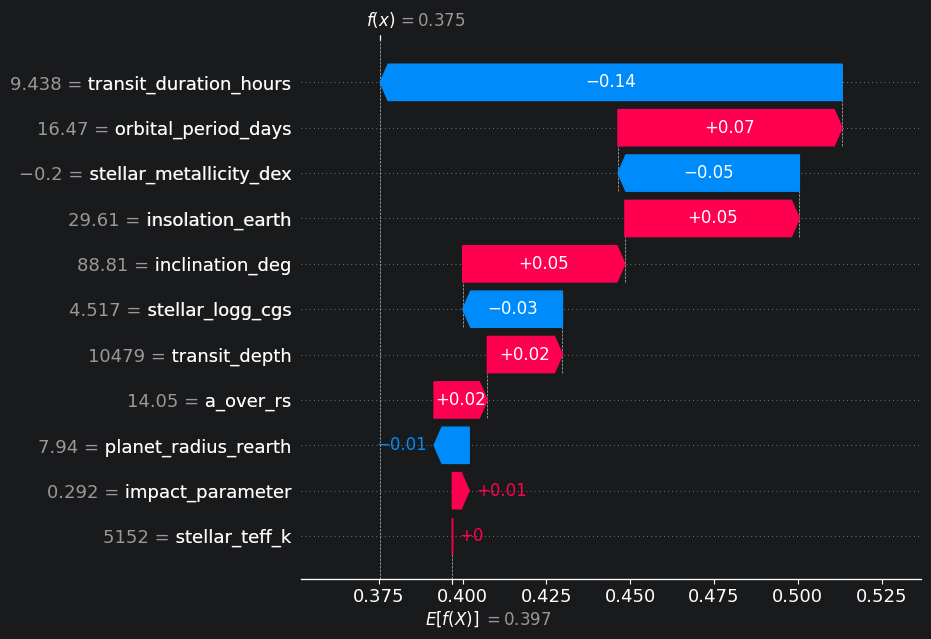

Deploy ID: deploy_f2
Model: knn (f2)
Threshold: 0.363636
Positive-class probability: 0.375377
Negative-class probability: 0.624623
Score (same as positive-class probability): 0.375377
Prediction: 1
Explainer kind: kernel


transit_duration_hours    -0.137834
orbital_period_days        0.066874
stellar_metallicity_dex   -0.054133
insolation_earth           0.052052
inclination_deg            0.048391
stellar_logg_cgs          -0.029754
transit_depth              0.022413
a_over_rs                  0.015897
planet_radius_rearth      -0.010495
impact_parameter           0.005045
Name: shap_value, dtype: float64

<Figure size 640x480 with 0 Axes>

In [7]:
sample_row_f2 = KOI_test_set.loc[:, FINAL_FEATURE_COLUMNS].iloc[[2]].copy()
background_f2 = evaluation_sets["KOI_test"][0]

f2_row_explanation = predict_and_explain_single_row(
    deployed_models,
    deploy_id="deploy_f2",
    row=sample_row_f2,
    background_data=background_f2,
    feature_columns=FINAL_FEATURE_COLUMNS,
    max_background_rows=200,
    random_state=42,
    kernel_nsamples=200,
    make_waterfall_plot=True,
    show_waterfall=True,
)

print(f"Deploy ID: {f2_row_explanation['deploy_id']}")
print(f"Model: {f2_row_explanation['model_name']} ({f2_row_explanation['profile']})")
print(f"Threshold: {f2_row_explanation['threshold']:.6f}")
print(f"Positive-class probability: {f2_row_explanation['probability_positive']:.6f}")
print(f"Negative-class probability: {f2_row_explanation['probability_negative']:.6f}")
print(f"Score (same as positive-class probability): {f2_row_explanation['score']:.6f}")
print(f"Prediction: {f2_row_explanation['prediction']}")
print(f"Explainer kind: {f2_row_explanation['explainer_kind']}")

f2_row_explanation["shap_values"].head(10)